  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   419  100   419    0     0   2063      0 --:--:-- --:--:-- --:--:--  2074
random preview:
     Outlook Temperature Humidity    Wind Play Tennis
0      Sunny         Hot     High    Weak          No
7      Sunny        Mild     High    Weak          No
4       Rain        Cool   Normal    Weak         Yes
8      Sunny        Cool   Normal    Weak         Yes
6   Overcast        Cool   Normal  Strong         Yes
1      Sunny         Hot     High  Strong          No
13      Rain        Mild     High  Strong          No

columns: ['Outlook', 'Temperature', 'Humidity', 'Wind', 'Play Tennis']


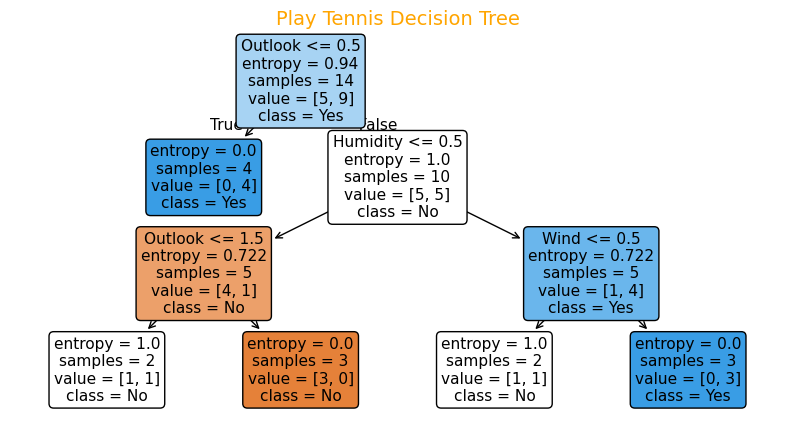

predictions: [1 0 0]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [ ]:
# step 1: dataset
!curl -L -o play_tennis.csv https://gist.githubusercontent.com/DiogoRibeiro7/c6590d0cf119e87c39e31c21a9c0f3a8/raw/PlayTennis.csv

# step 2: load
import pandas as pd
df = pd.read_csv("play_tennis.csv")

print("random preview:")
print(df.sample(7))   # shows different rows every run
print("\ncolumns:", list(df.columns))

# step 3: encode text
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in df.columns:
    df[col] = le.fit_transform(df[col])

# step 4: features & target
X = df.drop(columns=["Play Tennis"])
y = df["Play Tennis"]

# step 5: decision tree (slightly different settings so tree changes)
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

clf = DecisionTreeClassifier(criterion="entropy", random_state=1, max_depth=3)
clf.fit(X, y)

# step 6: tree viz
plt.figure(figsize=(10,5))
plot_tree(clf,
          feature_names=X.columns,
          class_names=["No", "Yes"],
          filled=True,
          rounded=True)
plt.title("Play Tennis Decision Tree", fontsize=14, color="orange")
plt.show()

# step 7: test predictions (multiple)
samples = [[0, 2, 1, 0],   # Sunny, Mild, High, Weak
           [1, 0, 0, 1],   # Overcast, Hot, High, Strong
           [2, 1, 0, 0]]   # Rain, Cool, High, Weak
print("predictions:", clf.predict(samples))
